In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('ResumeDataSet.csv')
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [3]:
df.isnull().sum()

Category    0
Resume      0
dtype: int64

In [4]:
print(df.shape)
print(df.info())

(962, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  962 non-null    object
 1   Resume    962 non-null    object
dtypes: object(2)
memory usage: 15.2+ KB
None


In [5]:
unique_categories = df['Category'].unique()
print(unique_categories)

['Data Science' 'HR' 'Advocate' 'Arts' 'Web Designing'
 'Mechanical Engineer' 'Sales' 'Health and fitness' 'Civil Engineer'
 'Java Developer' 'Business Analyst' 'SAP Developer' 'Automation Testing'
 'Electrical Engineering' 'Operations Manager' 'Python Developer'
 'DevOps Engineer' 'Network Security Engineer' 'PMO' 'Database' 'Hadoop'
 'ETL Developer' 'DotNet Developer' 'Blockchain' 'Testing']


In [6]:
df['Category'].value_counts()

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness           30
PMO                          30
Electrical Engineering       30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64

In [3]:
# Creating the bar plot
import pandas as pd

df = pd.read_csv("ResumeDataSet.csv")
import plotly.express as px
import plotly.graph_objects as go
# Create a new DataFrame for plotting
plot_data = pd.DataFrame({
    'Category': df['Category'].value_counts().index,
    'Count': df['Category'].value_counts().values
})
plot_data.head()
fig = px.bar(plot_data, x='Category', y='Count',
             color='Category', 
             labels={'Category': 'Job', 'Count': 'Count'},
             color_discrete_sequence=px.colors.qualitative.Set3)

fig.update_layout(
    title='Count of a particular Job',
    xaxis_title='Job Type',
    yaxis_title='Count',
    legend_title='Job Categories',
    showlegend=True,
    xaxis=dict(tickangle=-30),
    font=dict(family='Times New Roman', size=12),
    plot_bgcolor='white'
)

fig.show()

In [4]:
fig = px.pie(plot_data, values='Count', names='Category',
             title='Pie plot of Job Category',
             color_discrete_sequence=px.colors.sequential.RdBu,
             hole=0.4,
             labels={'Category': 'Categories', 'Count': 'Count'},
             opacity=0.8,
             )

# Customize the layout
fig.update_layout(
    legend_title='Categories',
    font=dict(family='Times New Roman', size=16, color='black'),
    plot_bgcolor='white',
    margin=dict(t=50, b=50, l=50, r=50)
)

fig.show()

In [5]:
# Preprocessing libraries
import re
from sklearn.preprocessing import LabelEncoder
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer 
import string
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sakth\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sakth\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [6]:
def resumeKeywords(txt):   # sourcery skip: avoid-builtin-shadow, list-comprehension
    cleanText = re.sub('http\S+\s', ' ', txt) # Removing URLs
    cleanText = re.sub('#\S+\s', ' ', cleanText) # Removing hashtags
    cleanText = re.sub('@\S+', '  ', cleanText)  # Removing mentions
    cleanText = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', cleanText) # Removing punctuations
    cleanText = re.sub(r'[^\x00-\x7f]', ' ', cleanText) # Removing non-ASCII characters
    cleanText = re.sub('\s+', ' ', cleanText) # Replace multiple spaces with a single space
    cleanText = cleanText.strip() # Removing leading and trailing whitespaces
    
    #------------Tokenizing Cleaned Text--------------------------------------------------------
    # Tokenizing our cleaned text
    tokenizer = nltk.tokenize.RegexpTokenizer('\w+')
    tokens = tokenizer.tokenize(cleanText)
    # Now lower everything and storing it in new variable words
    words = []
    for word in tokens:
        words.append(word.lower())
    #--------------------------------------------------------------------------------------------

    #-------------Removing Stop Words------------------------------------------------------------
    stopwords = nltk.corpus.stopwords.words('english')
    words_new = []
    for word in words:
        if word not in stopwords:
            words_new.append(word)
    #--------------------------------------------------------------------------------------------
    #-----------Performing Lemmatization---------------------------------------------------------
    wn = WordNetLemmatizer() 
    lemm_text = [wn.lemmatize(word) for word in words_new]
    #--------------------------------------------------------------------------------------------
    #----------Converting List into String-------------------------------------------------------
    processed_text = ' '.join(lemm_text)
    
    return processed_text

In [7]:
resumeKeywords(" https://www.github.com Software Engineer with 2 years of experience in Data Structures and Algorithms Agile Scrum, SDLC, C++, Java MVC, JavaScript, Web Development, Python " +
               "Data Science, Machine Learning / AI, and Mainframe technologies Programming Languages: 	C/C++, Java, Python, SQL, JCL, Cobol, DB2" + 
               "Frameworks: %#####	Java Spring, Spring boot, React, Angular, NodeJs" +
               "Tools: 	GIT, Visual Studio Code, Sublime, Spyder, Jupyter Notebook, Bluezone, Netbeans, Jira, Confluence, Kanban, CI/CD (Jenkins, GitLab, Azure-Devops), AWS," + 
               "Data-Bricks Libraries: 	NumPy, Pandas, Matplotlib, nltk, Scikit learn, TensorFlow, Keras Other: 	Problem-Solving, Quick Learner, Time-Management")

'software engineer 2 year experience data structure algorithm agile scrum sdlc c java mvc javascript web development python data science machine learning ai mainframe technology programming language c c java python sql jcl cobol db2frameworks java spring spring boot react angular nodejstools git visual studio code sublime spyder jupyter notebook bluezone netbeans jira confluence kanban ci cd jenkins gitlab azure devops aws data brick library numpy panda matplotlib nltk scikit learn tensorflow kera problem solving quick learner time management'

In [8]:
df['Processed_Resume'] = df['Resume'].apply(lambda x: resumeKeywords(x))
df.head()

,Category,Resume,Processed_Resume
0,Data Science,Skills * Programming Languages: Python (pandas...,skill programming language python panda numpy ...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,education detail may 2013 may 2017 b e uit rgp...
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",area interest deep learning control system des...
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,skill r python sap hana tableau sap hana sql s...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",education detail mca ymcaust faridabad haryana...


In [9]:
#Generating WordCloud from the cleaned text
!pip install wordcloud
from wordcloud import WordCloud

In [10]:
# Join the cleaned text into a single string
text = ' '.join(df['Processed_Resume'])

# Create a word cloud
wordcloud = WordCloud(background_color='white',
                      width=800,
                      height=600,
                      max_words=100,
                      colormap='viridis'
                      ).generate(text)

# Convert word cloud to an image
wordcloud_image = wordcloud.to_image()

# Display the word cloud using Plotly as an image
fig = px.imshow(wordcloud_image)
fig.update_layout(
    title='Word Cloud of Cleaned Text',
    xaxis_showticklabels=False,
    yaxis_showticklabels=False,
    plot_bgcolor='white'
)
fig.show()

In [11]:
# Label encoding our Category
label = LabelEncoder()
df['Encoded_Category'] = label.fit_transform(df['Category'])
df.head()

,Category,Resume,Processed_Resume,Encoded_Category
0,Data Science,Skills * Programming Languages: Python (pandas...,skill programming language python panda numpy ...,6
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,education detail may 2013 may 2017 b e uit rgp...,6
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",area interest deep learning control system des...,6
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,skill r python sap hana tableau sap hana sql s...,6
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",education detail mca ymcaust faridabad haryana...,6


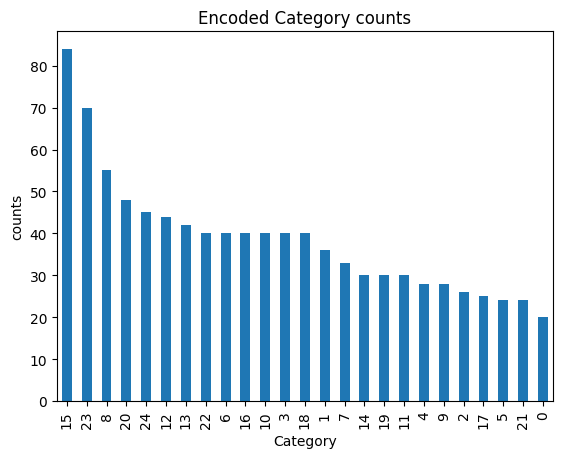

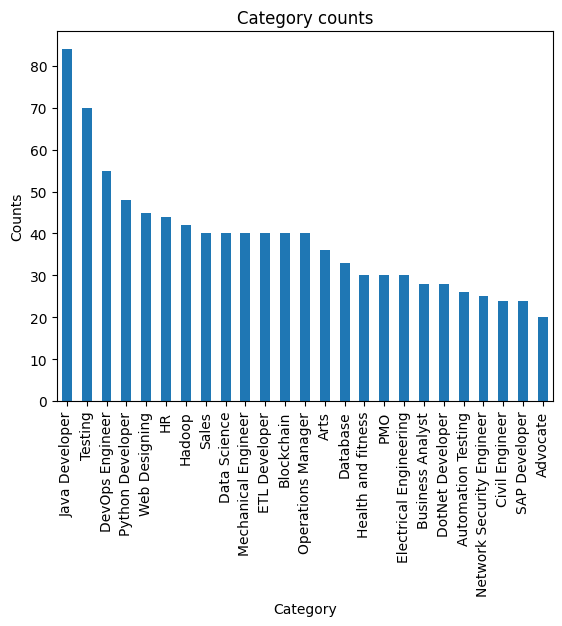

In [13]:
# Creating the bar plot
import matplotlib.pyplot as plt
df['Encoded_Category'].value_counts().plot(kind = 'bar', title='Encoded Category counts', xlabel='Category', ylabel='counts')
plt.show()
df['Category'].value_counts().plot(kind = 'bar', title='Category counts', xlabel='Category', ylabel='Counts')
plt.show()

In [14]:
category_mapping = {
    15: "Java Developer",
    23: "Testing",
    8: "DevOps Engineer",
    20: "Python Developer",
    24: "Web Designing",
    12: "HR",
    13: "Hadoop",
    3: "Blockchain",
    10: "ETL Developer",
    18: "Operations Manager",
    6: "Data Science",
    22: "Sales",
    16: "Mechanical Engineer",
    1: "Arts",
    7: "Database",
    11: "Electrical Engineering",
    14: "Health and fitness",
    19: "PMO",
    4: "Business Analyst",
    9: "DotNet Developer",
    2: "Automation Testing",
    17: "Network Security Engineer",
    21: "SAP Developer",
    5: "Civil Engineer",
    0: "Advocate",
}

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english')

tfidf.fit(df['Processed_Resume'])
requiredText  = tfidf.transform(df['Processed_Resume'])
print(requiredText)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 155341 stored elements and shape (962, 6562)>
  Coords	Values
  (0, 118)	0.06453783899846323
  (0, 268)	0.04632697838273315
  (0, 298)	0.031126979945512483
  (0, 317)	0.025361912989866155
  (0, 340)	0.033319272390464866
  (0, 370)	0.029288428444891598
  (0, 495)	0.13903194496767213
  (0, 497)	0.07851286854091813
  (0, 500)	0.15656008367123686
  (0, 505)	0.02096423266463051
  (0, 512)	0.026190077390818307
  (0, 523)	0.04632697838273315
  (0, 526)	0.03727134831379874
  (0, 622)	0.04632697838273315
  (0, 640)	0.053810183291968954
  (0, 643)	0.08098518487138881
  (0, 645)	0.02899820504264113
  (0, 646)	0.06518168127424176
  (0, 650)	0.10712314267369262
  (0, 667)	0.03771995525102985
  (0, 700)	0.027461726023211917
  (0, 703)	0.03503454597093106
  (0, 786)	0.015483241225769256
  (0, 796)	0.08098518487138881
  (0, 829)	0.024012779374943182
  :	:
  (961, 5265)	0.040106642718727006
  (961, 5313)	0.034685407248807254
  (961, 5323)	0.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(requiredText, df['Encoded_Category'], test_size=0.25, random_state=42)
print(X_train.shape)

print(X_test.shape)

(721, 6562)
(241, 6562)


In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

mnb = MultinomialNB()
mnb.fit(X_train,y_train)
y_pred1 = mnb.predict(X_test)
print('Accuracy: ', accuracy_score(y_test,y_pred1)*100, ' % \n')
print(classification_report(y_test, y_pred1))

Accuracy:  94.1908713692946  % 

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       1.00      1.00      1.00         8
           2       1.00      0.83      0.91         6
           3       1.00      1.00      1.00        10
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         9
           6       1.00      1.00      1.00         9
           7       1.00      1.00      1.00         9
           8       1.00      0.88      0.94        17
           9       1.00      0.30      0.46        10
          10       1.00      1.00      1.00         7
          11       1.00      1.00      1.00         7
          12       1.00      0.93      0.97        15
          13       1.00      1.00      1.00         6
          14       1.00      1.00      1.00        10
          15       0.66      1.00      0.79        21
          16       1.00      1.00      1.00     

In [18]:
knc = OneVsRestClassifier(KNeighborsClassifier())
knc.fit(X_train,y_train)
y_pred2 = knc.predict(X_test)
print('Accuracy: ', accuracy_score(y_test,y_pred2)*100, ' %')
print(classification_report(y_test, y_pred2))

Accuracy:  98.3402489626556  %
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6
           3       1.00      1.00      1.00        10
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         9
           6       1.00      0.78      0.88         9
           7       1.00      1.00      1.00         9
           8       1.00      0.88      0.94        17
           9       1.00      1.00      1.00        10
          10       1.00      1.00      1.00         7
          11       1.00      1.00      1.00         7
          12       1.00      1.00      1.00        15
          13       1.00      1.00      1.00         6
          14       1.00      1.00      1.00        10
          15       1.00      1.00      1.00        21
          16       1.00      1.00      1.00       

In [19]:
!pip install tensorflow

In [20]:
!pip install pandas

In [21]:
import pandas as pd

df = pd.read_csv("ResumeDataSet.csv")

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.feature_extraction.text import TfidfVectorizer

# Label encoding
label = LabelEncoder()
df['Encoded_Category'] = label.fit_transform(df['Category'])

# Define the maximum number of words
max_words = 5000

# ✅ FIXED COLUMN NAME HERE
tokenizer = Tokenizer(num_words=max_words, split=' ')
tokenizer.fit_on_texts(df['Resume'])
X = tokenizer.texts_to_sequences(df['Resume'])
X = pad_sequences(X, maxlen=100)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, df['Encoded_Category'], test_size=0.25, random_state=42
)

# Model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128))
model.add(SpatialDropout1D(0.2))
model.add(LSTM(100))
model.add(Dense(32, activation='relu'))
model.add(Dense(len(label.classes_), activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=64,
    verbose=0
)

# Predict
y_pred_rnn_prob = model.predict(X_test)
y_pred3 = y_pred_rnn_prob.argmax(axis=-1)

accuracy_rnn = accuracy_score(y_test, y_pred3)

print('RNN Model Accuracy: {:.2f}%'.format(accuracy_rnn * 100))
print(classification_report(y_test, y_pred3))

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
RNN Model Accuracy: 99.17%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6
           3       1.00      1.00      1.00        10
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         9
           6       0.90      1.00      0.95         9
           7       0.90      1.00      0.95         9
           8       1.00      0.88      0.94        17
           9       1.00      1.00      1.00        10
          10       1.00      1.00      1.00         7
          11       1.00      1.00      1.00         7
          12       1.00      1.00      1.00        15
          13       1.00      1.00      1.00         6
          14       1.00      1.00      1.00        10
          15       1.00      1.00      1.00        21
          16    

In [22]:
import pickle

# Save only the trained RNN model
pickle.dump(model, open('rnn.pkl', 'wb'))

In [23]:
resume_1 = """I am a data scientist specializing in machine
learning, deep learning, and computer vision. With
a strong background in mathematics, statistics,
and programming, I am passionate about
uncovering hidden patterns and insights in data.
I have extensive experience in developing
predictive models, implementing deep learning
algorithms, and designing computer vision
systems. My technical skills include proficiency in
Python, Sklearn, TensorFlow, and PyTorch.
What sets me apart is my ability to effectively
communicate complex concepts to diverse
audiences. I excel in translating technical insights
into actionable recommendations that drive
informed decision-making.
If you're looking for a dedicated and versatile data
scientist to collaborate on impactful projects, I am
eager to contribute my expertise. Let's harness the
power of data together to unlock new possibilities
and shape a better future.
Contact & Sources
Email: 611noorsaeed@gmail.com
Phone: 03442826192
Github: https://github.com/611noorsaeed
Linkdin: https://www.linkedin.com/in/noor-saeed654a23263/
Blogs: https://medium.com/@611noorsaeed
Youtube: Artificial Intelligence
ABOUT ME
WORK EXPERIENCE
SKILLES
NOOR SAEED
LANGUAGES
English
Urdu
Hindi
I am a versatile data scientist with expertise in a wide
range of projects, including machine learning,
recommendation systems, deep learning, and computer
vision. Throughout my career, I have successfully
developed and deployed various machine learning models
to solve complex problems and drive data-driven
decision-making
Machine Learnine
Deep Learning
Computer Vision
Recommendation Systems
Data Visualization
Programming Languages (Python, SQL)
Data Preprocessing and Feature Engineering
Model Evaluation and Deployment
Statistical Analysis
Communication and Collaboration
"""

In [24]:
import pickle

# Load model and vectorizer
clf = pickle.load(open('knc.pkl', 'rb'))
tfidf = pickle.load(open('tfidf.pkl', 'rb'))   # ✅ added

# Sample input (replace with your resume text)
resume_1 = "Your resume text here"   # ✅ added

# Simple cleaning function (replace if you already have one)
def resumeKeywords(text):
    return text.lower()   # ✅ basic fix

cleaned_resume = resumeKeywords(resume_1)

# Transform
input_features = tfidf.transform([cleaned_resume])

# Predict
prediction_id = clf.predict(input_features)[0]

# Mapping (example)
category_mapping = {
    0: "Data Science",
    1: "HR",
    2: "Advocate",
    3: "Arts"
}   # ✅ add your actual mapping

category_name = category_mapping.get(prediction_id, "Unknown")

print("Predicted Category:", category_name)
print(prediction_id)

Predicted Category: Advocate
2


In [25]:
import pickle

# Load the trained  Multinomial Naive Bayes model
mnb = pickle.load(open('mnb.pkl', 'rb'))

# Clean the input resume
cleaned_resume = resumeKeywords(resume_1)

# Transform the cleaned resume using the trained TfidfVectorizer
input_features = tfidf.transform([cleaned_resume])

# Make the prediction using the loaded classifier
prediction_id = mnb.predict(input_features)[0]

category_name = category_mapping.get(prediction_id, "Unknown")

print("Predicted Category:", category_name)
print(prediction_id)

Predicted Category: Unknown
15


In [26]:
from tensorflow.keras.models import load_model
import numpy as np

# Load model
rnn = load_model('rnn.h5')

# Max words
max_words = 5000

# Tokenizer (✅ FIXED COLUMN NAME)
tokenizer = Tokenizer(num_words=max_words, split=' ')
tokenizer.fit_on_texts(df['Resume'])   # 🔥 changed here

# Input
resume_1 = "Your resume text here"

def resumeKeywords(text):
    return text.lower()

cleaned_resume = resumeKeywords(resume_1)

# Convert to sequence
input_sequence = tokenizer.texts_to_sequences([cleaned_resume])
input_sequence = pad_sequences(input_sequence, maxlen=100)

# Prediction
predicted_probabilities = rnn.predict(input_sequence)
prediction_id = np.argmax(predicted_probabilities)

# Mapping (example)
category_mapping = {
    6: "Data Science"
}

category_name = category_mapping.get(prediction_id, "Unknown")

print("Predicted Category:", category_name)
print("Predicted Category ID:", prediction_id)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
Predicted Category: Unknown
Predicted Category ID: 12
